Team info:

Project Title: MLB Pitcher Injury

Team name: Group 26

Team member names and PIDs:
Carter Scheimreif carterschei,
Nicholas Fitti,
Dean Peri,
Trey Potter,
Andrew Hitt

Project introduction:

Initial description of the project topic:
Looking at Tommy John data history and seeing the effects of arm angle, pitch velocity, spin rate, and pithcer tempo on how often the injury happens.

Potential research questions you plan to address: How Spin Rate, Velocity, arm angle, and pitcher tempo effects how often Tommy John surgery happen

Description of potential source data that would be relevant (including links or references if possible).

https://www.fangraphs.com/roster-resource/injury-report?groupby=injury&timeframe=current&season=2025 (Injury Data)


https://www.espn.com/mlb/injuries (Injury Data)


https://baseballsavant.mlb.com/leaderboard/pitch-arsenals (Average velocity and Spin)


https://baseballsavant.mlb.com/leaderboard/pitcher-arm-angles (Arm angle)


https://baseballsavant.mlb.com/leaderboard/pitch-tempo (Pitcher Tempo)

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
injuryData = pd.read_csv('Tommy John Injury data 2020-2025.csv')
pitchData = pd.read_csv('pitcherdata.csv')
arm_angle_bk = pd.read_csv('pitcher_arm_angles_bk.csv')
arm_angle_os = pd.read_csv('pitcher_arm_angles_os.csv')
arm_angle_fb = pd.read_csv('pitcher_arm_angles_fb.csv')


In [3]:
pitchData.columns = pitchData.columns.str.replace('"', "")

def normalize_pitch_name(name):
    name = str(name).replace('"', '').strip()
    if "," in name:
        parts = name.split(",")
        name = parts[1].strip() + " " + parts[0].strip()
    return name.lower().replace(" ", "").replace(".", "")

def normalize_injury_name(name):
    if pd.isna(name):
        return ""
    return (
        str(name)
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace(",", "")
        .strip()
    )

# Normalize names
pitchData["Name"] = pitchData["last_name, first_name"]
pitchData["CleanName"] = pitchData["Name"].apply(normalize_pitch_name)
injuryData["CleanName"] = injuryData["Name"].apply(normalize_injury_name)

# Merge
mergedData = pd.merge(
    pitchData,
    injuryData[["CleanName", "Injury / Surgery"]],
    on="CleanName",
    how="left"
)

# Tommy John binary flag
mergedData["HadTommyJohn"] = mergedData["Injury / Surgery"].str.contains("Tommy John", case=False, na=False).astype(int)

# FINAL DF
finalDF = mergedData[[
    "Name",
    "year",
    "n",
    "n_fastball_formatted",
    "fastball_avg_speed",
    "fastball_avg_spin",
    "n_breaking_formatted",
    "breaking_avg_speed",
    "breaking_avg_spin",
    "n_offspeed_formatted",
    "offspeed_avg_speed",
    "offspeed_avg_spin",
    "HadTommyJohn"
]]

print(finalDF.head())
print(finalDF["HadTommyJohn"].value_counts())

             Name  year     n  n_fastball_formatted  fastball_avg_speed  \
0  Colon, Bartolo  2015  2683                  82.6                88.9   
1   Burnett, A.J.  2015  2490                  61.8                91.6   
2     Hudson, Tim  2015  1848                  77.2                87.0   
3   Buehrle, Mark  2015  2818                  70.3                82.9   
4    Sabathia, CC  2015  2693                  63.6                90.2   

   fastball_avg_spin  n_breaking_formatted  breaking_avg_speed  \
0               2161                  10.0                82.8   
1               2009                  29.4                82.3   
2               2054                  11.6                75.8   
3               1996                   8.6                71.7   
4               2075                  22.5                79.6   

   breaking_avg_spin  n_offspeed_formatted  offspeed_avg_speed  \
0               2164                   7.4                82.6   
1               2023

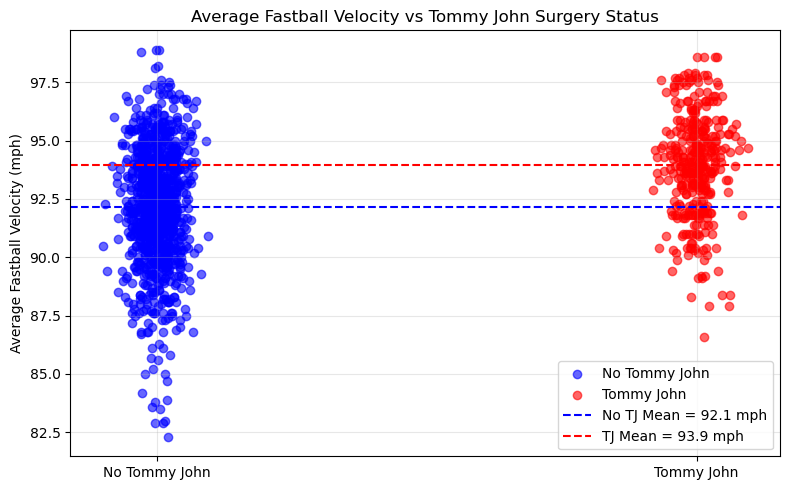

In [4]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Add small horizontal jitter to separate overlapping points
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # around x = 0

# Create figure
plt.figure(figsize=(8,5))

plt.scatter(jitter_no_tj, no_tj_pitchers["fastball_avg_speed"],
            color="blue", alpha=0.6, label="No Tommy John")
plt.scatter(jitter_tj, tj_pitchers["fastball_avg_speed"],
            color="red", alpha=0.6, label="Tommy John")

# Add horizontal mean lines for each group
mean_no_tj = no_tj_pitchers["fastball_avg_speed"].mean()
mean_tj = tj_pitchers["fastball_avg_speed"].mean()
plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} mph")
plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} mph")

# Labels and styling
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Fastball Velocity (mph)")
plt.title("Average Fastball Velocity vs Tommy John Surgery Status")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

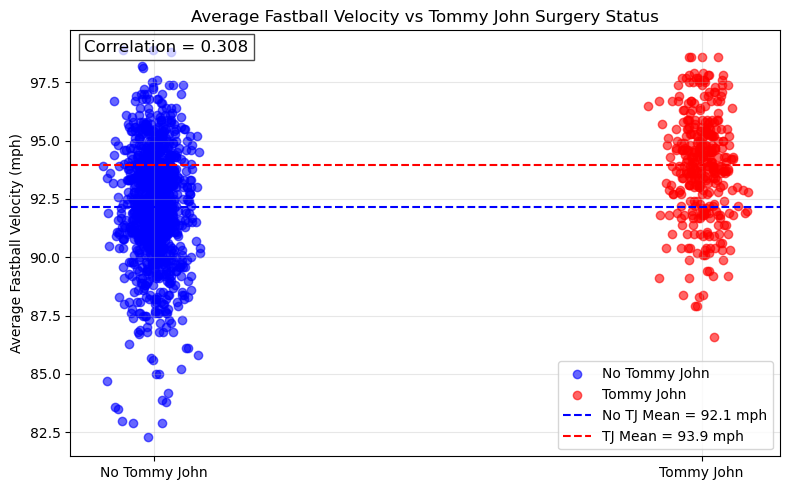

In [5]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["fastball_avg_speed"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["fastball_avg_speed"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["fastball_avg_speed"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["fastball_avg_speed"].mean()
mean_tj = tj_pitchers["fastball_avg_speed"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} mph")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} mph")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Fastball Velocity (mph)")
plt.title("Average Fastball Velocity vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

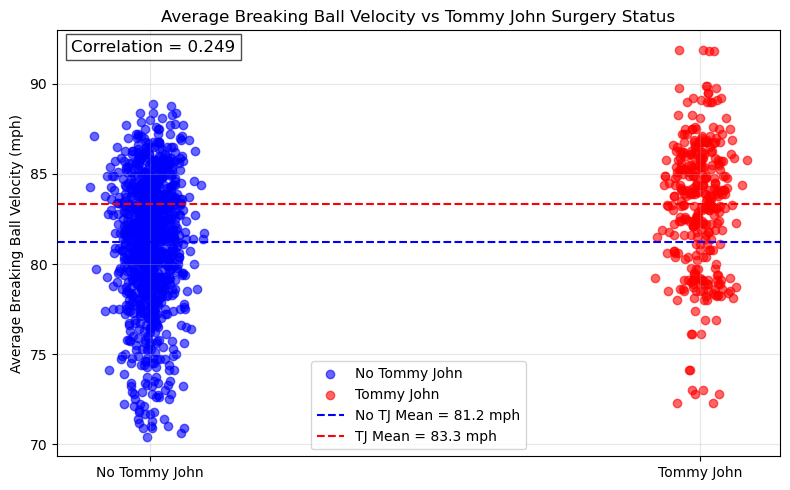

In [6]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["breaking_avg_speed"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["breaking_avg_speed"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["breaking_avg_speed"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["breaking_avg_speed"].mean()
mean_tj = tj_pitchers["breaking_avg_speed"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} mph")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} mph")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Breaking Ball Velocity (mph)")
plt.title("Average Breaking Ball Velocity vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

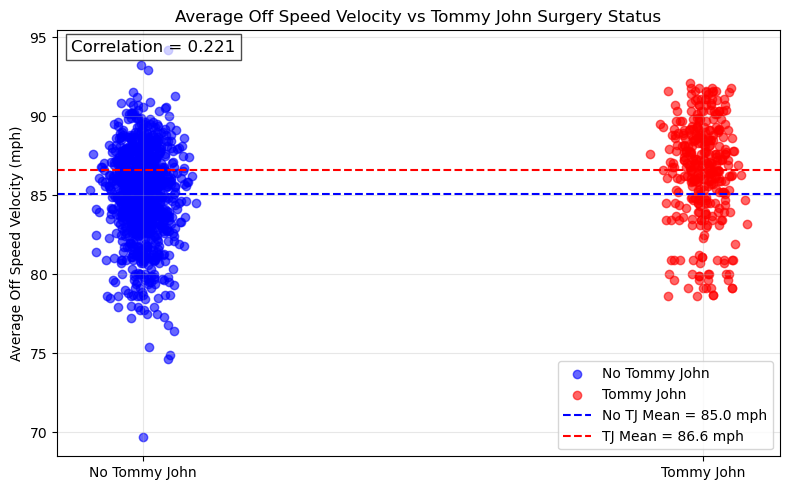

In [7]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["offspeed_avg_speed"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["offspeed_avg_speed"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["offspeed_avg_speed"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["offspeed_avg_speed"].mean()
mean_tj = tj_pitchers["offspeed_avg_speed"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} mph")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} mph")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Off Speed Velocity (mph)")
plt.title("Average Off Speed Velocity vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

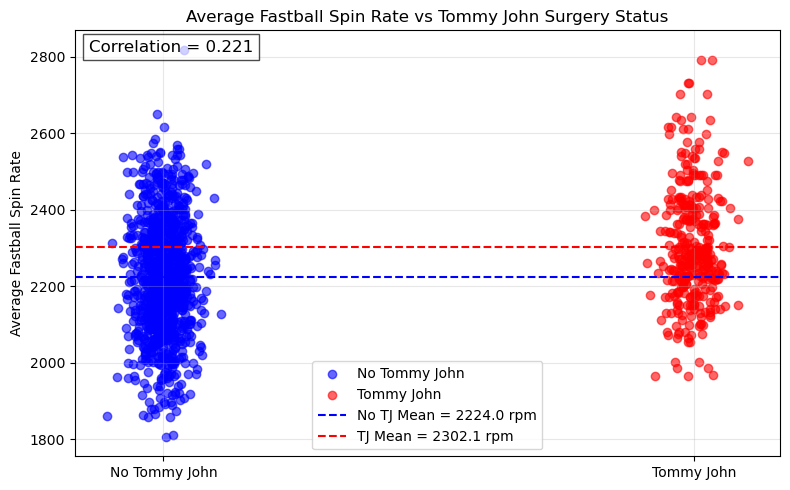

In [8]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["fastball_avg_spin"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["fastball_avg_spin"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["fastball_avg_spin"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["fastball_avg_spin"].mean()
mean_tj = tj_pitchers["fastball_avg_spin"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} rpm")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} rpm")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Fastball Spin Rate")
plt.title("Average Fastball Spin Rate vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

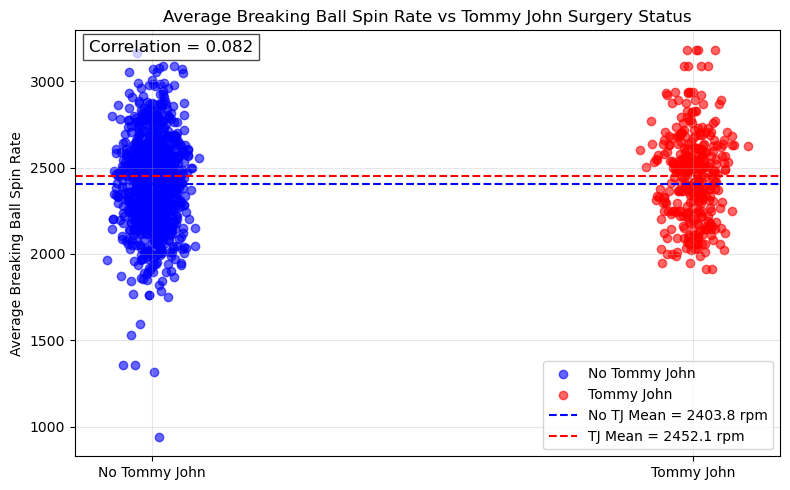

In [9]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["breaking_avg_spin"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["breaking_avg_spin"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["breaking_avg_spin"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["breaking_avg_spin"].mean()
mean_tj = tj_pitchers["breaking_avg_spin"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} rpm")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} rpm")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Breaking Ball Spin Rate")
plt.title("Average Breaking Ball Spin Rate vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

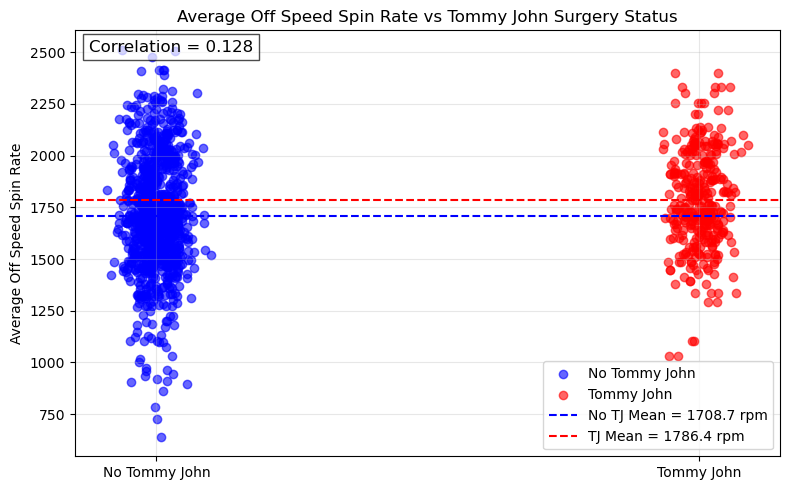

In [10]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["offspeed_avg_spin"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["offspeed_avg_spin"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["offspeed_avg_spin"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["offspeed_avg_spin"].mean()
mean_tj = tj_pitchers["offspeed_avg_spin"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} rpm")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} rpm")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Average Off Speed Spin Rate")
plt.title("Average Off Speed Spin Rate vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

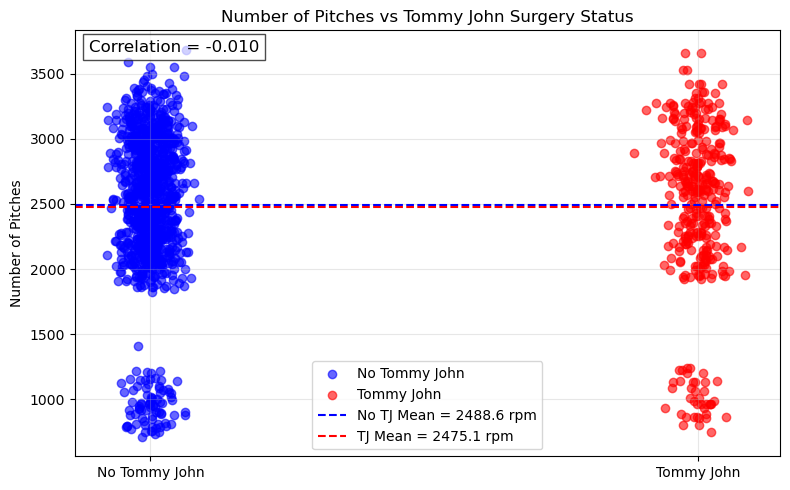

In [23]:
# Split by Tommy John status
tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 1]
no_tj_pitchers = finalDF[finalDF["HadTommyJohn"] == 0]

# Compute correlation
corr_value = finalDF["n"].corr(finalDF["HadTommyJohn"])

# Add jitter
jitter_tj = np.random.normal(1, 0.03, len(tj_pitchers))        # around x = 1
jitter_no_tj = np.random.normal(0, 0.03, len(no_tj_pitchers))  # aroune x = 0

plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(jitter_no_tj, no_tj_pitchers["n"],
            color="blue", alpha=0.6, label="No Tommy John")

plt.scatter(jitter_tj, tj_pitchers["n"],
            color="red", alpha=0.6, label="Tommy John")

# Mean lines
mean_no_tj = no_tj_pitchers["n"].mean()
mean_tj = tj_pitchers["n"].mean()

plt.axhline(mean_no_tj, color="blue", linestyle="--",
            label=f"No TJ Mean = {mean_no_tj:.1f} rpm")

plt.axhline(mean_tj, color="red", linestyle="--",
            label=f"TJ Mean = {mean_tj:.1f} rpm")

# Labels
plt.xticks([0, 1], ["No Tommy John", "Tommy John"])
plt.ylabel("Number of Pitches")
plt.title("Number of Pitches vs Tommy John Surgery Status")

# Add correlation text box
plt.text(
    0.02, 0.95,
    f"Correlation = {corr_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()